# **Рубежный контрол №1**
Вариант- 6
Задача: 1 Набор данных: 6 ФИО: Герасимович Никита Иванович Группа: ИУ5-65Б

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных (предполагается, что файл находится в текущей директории Colab)
df = pd.read_csv('Admission_Predict.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB
None
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3   

Проверяем наличие пропусков, удаляем строки с отсутствующими значениями и убираем лишние пробелы в названиях колонок.

In [3]:
# Проверка пропусков
print("Пропуски до очистки:", df.isnull().sum().sum())

# Удаление строк с пропусками (если они есть)
df_clean = df.dropna().copy()

# Очистка названий колонок (в исходном файле есть пробел после LOR)
df_clean.columns = df_clean.columns.str.strip()

print(f"Размер данных после очистки: {df_clean.shape}")
print("Пропуски после очистки:", df_clean.isnull().sum().sum())

Пропуски до очистки: 0
Размер данных после очистки: (400, 9)
Пропуски после очистки: 0


Вычисляем матрицу корреляций Пирсона и визуализируем её с помощью тепловой карты для оценки силы и направления взаимосвязей.

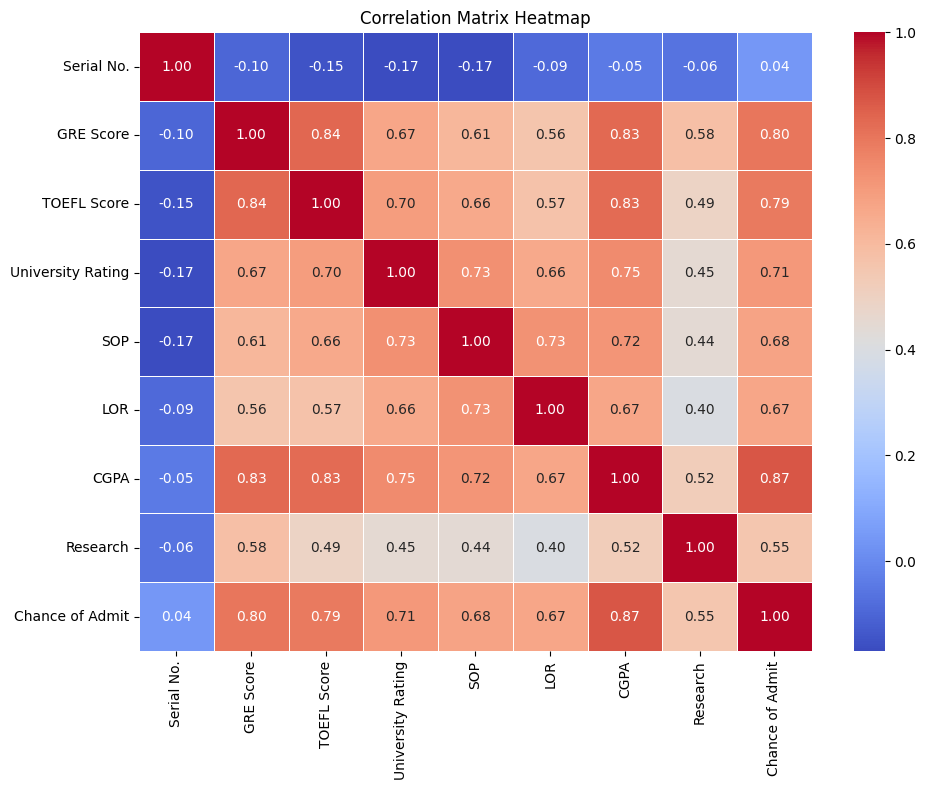

In [4]:
# Расчёт корреляционной матрицы
corr_matrix = df_clean.corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

Строим парные диаграммы (pairplot) для всех числовых признаков, чтобы увидеть распределения и попарные зависимости.

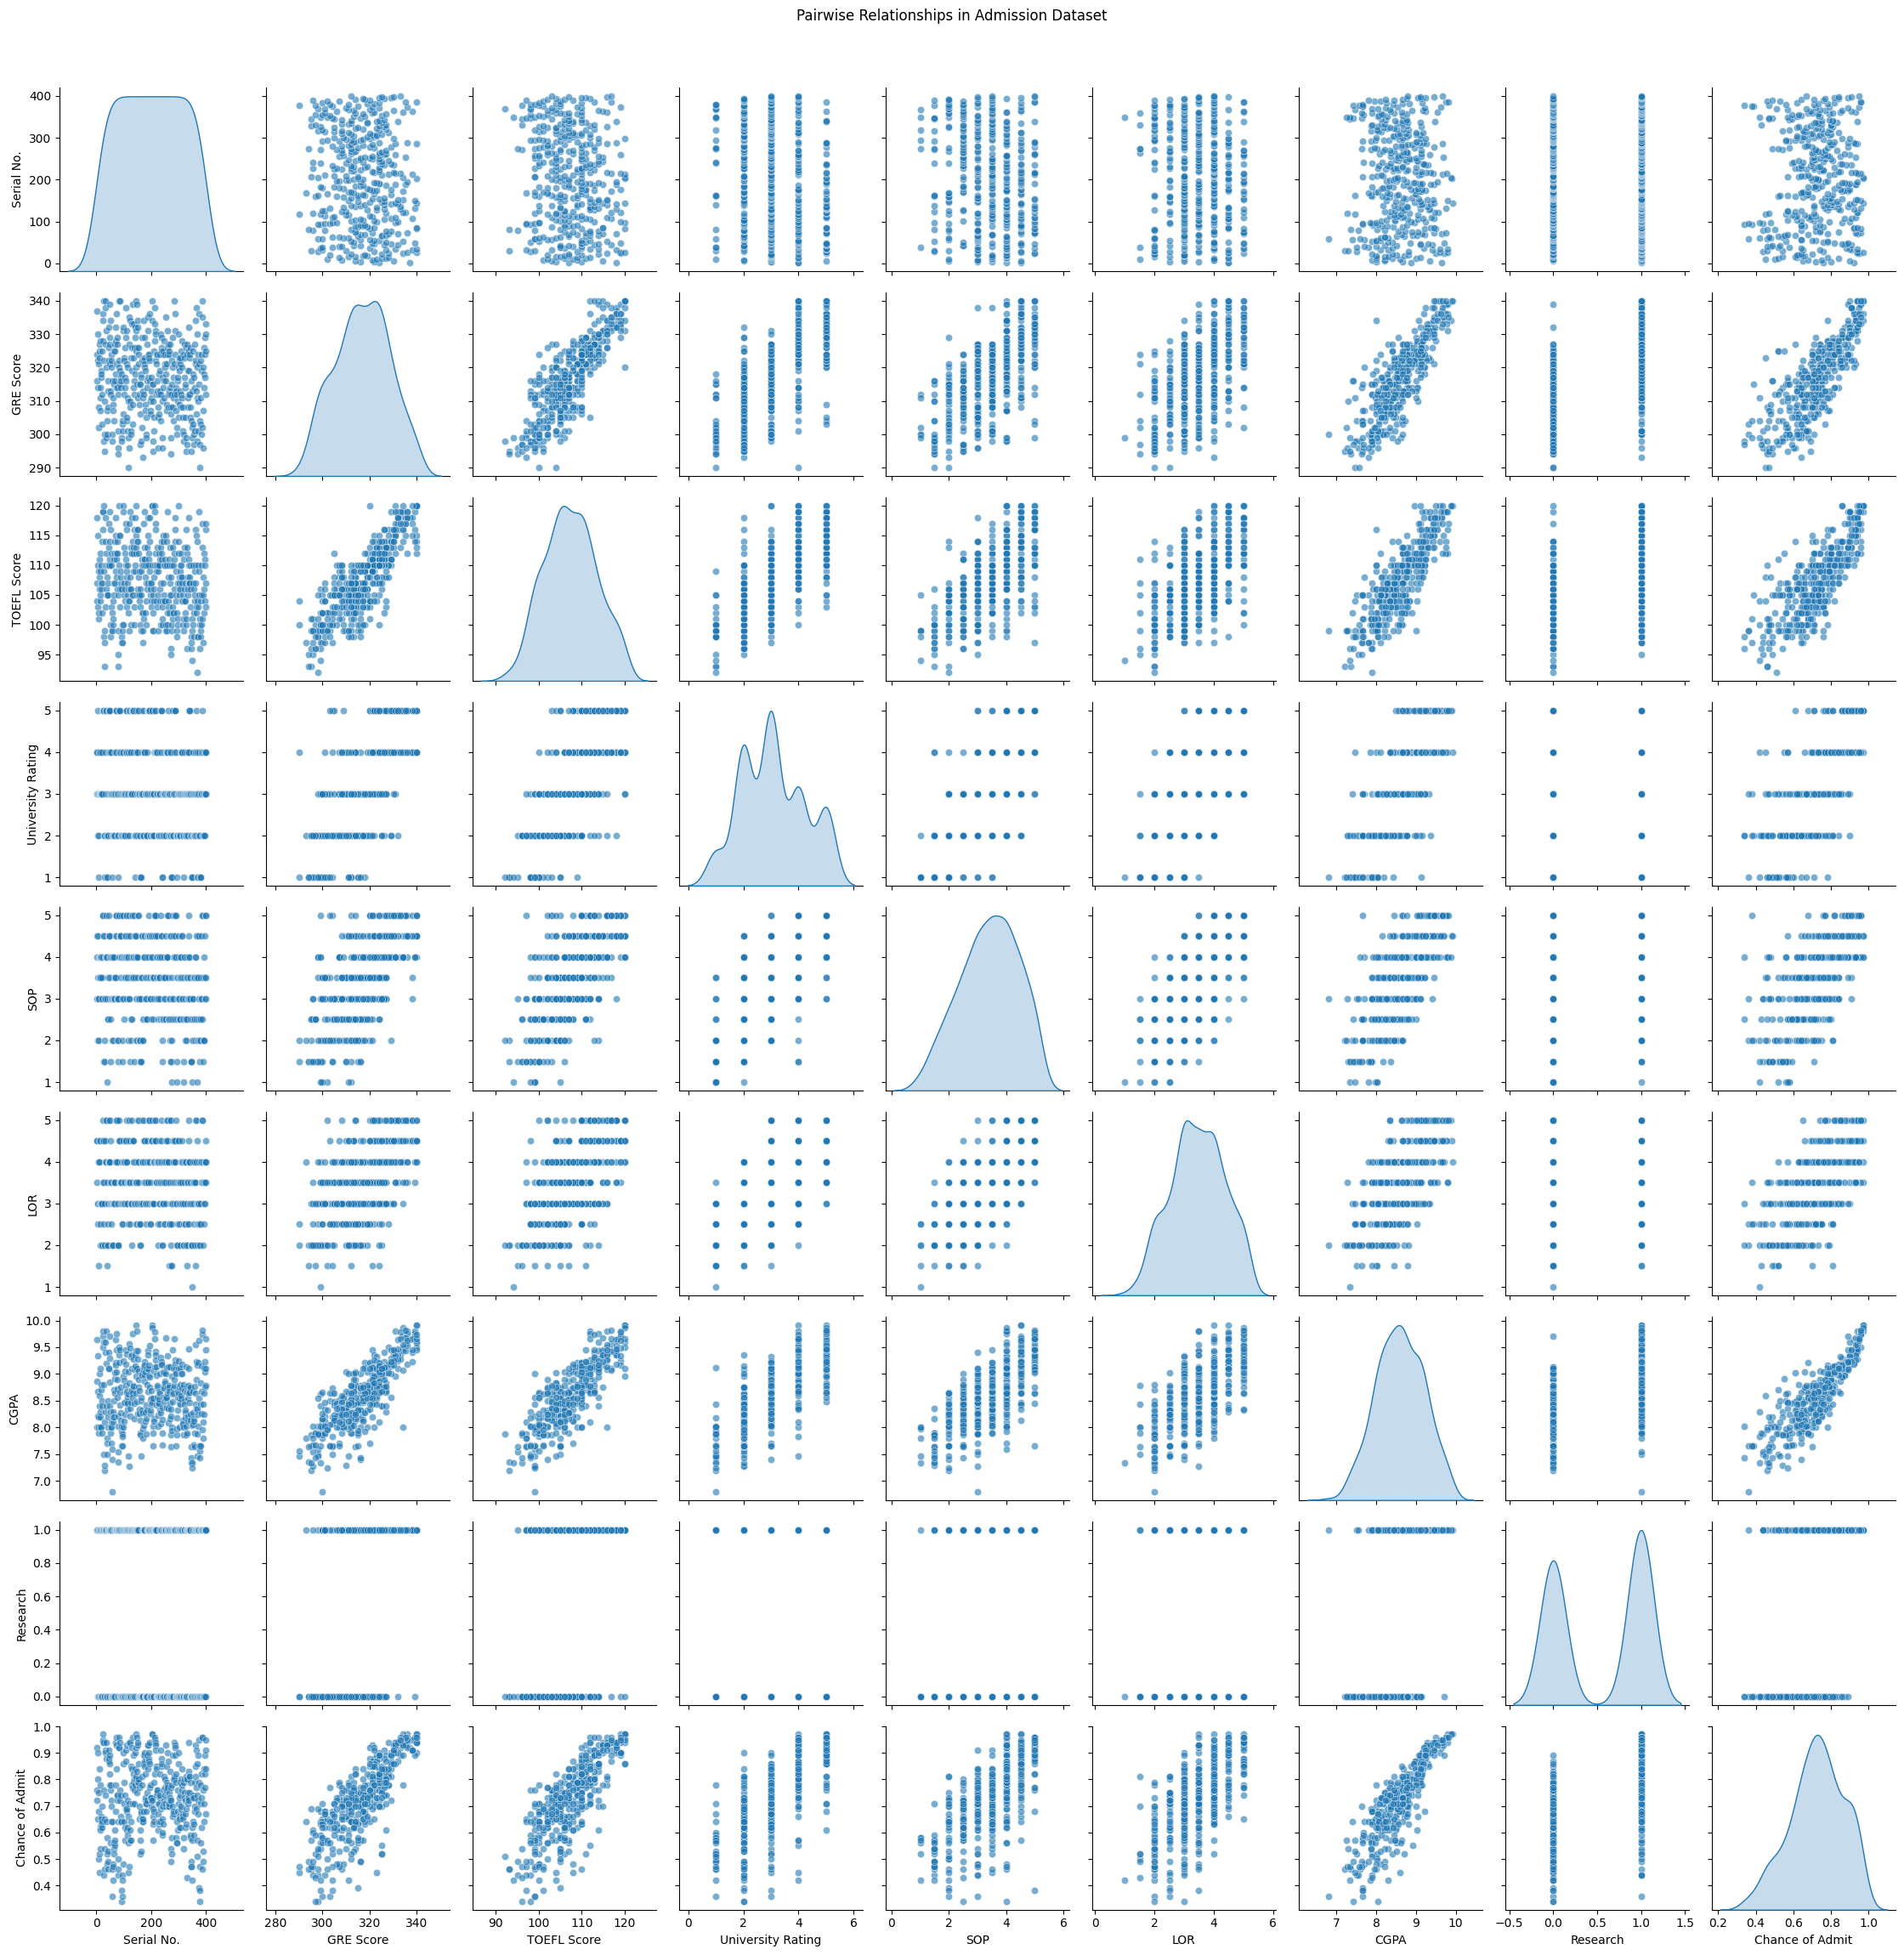

In [5]:
# Построение парных диаграмм
sns.pairplot(df_clean, diag_kind='kde', plot_kws={'alpha': 0.6}, corner=False)
plt.suptitle('Pairwise Relationships in Admission Dataset', y=1.02)
plt.tight_layout()
plt.show()

Выводим значения корреляции с целевой переменной и формулируем итоговые выводы о применимости машинного обучения и значимости признаков.

In [6]:
# Корреляция признаков с целевой переменной
target_corr = corr_matrix['Chance of Admit'].drop('Chance of Admit').sort_values(ascending=False)
print("Корреляция признаков с 'Chance of Admit':")
print(target_corr.round(3))


Корреляция признаков с 'Chance of Admit':
CGPA                 0.873
GRE Score            0.803
TOEFL Score          0.792
University Rating    0.711
SOP                  0.676
LOR                  0.670
Research             0.553
Serial No.           0.042
Name: Chance of Admit, dtype: float64

=== ВЫВОДЫ ===
1. Данные не содержат пропусков, что упрощает предобработку и позволяет сразу переходить к обучению моделей.
2. Наибольший линейный вклад в целевую переменную вносят CGPA (~0.80), GRE Score (~0.80) и TOEFL Score (~0.79).
3. Признаки Research, SOP и LOR имеют умеренную корреляцию (~0.55-0.64), но остаются информативными для нелинейных моделей.
4. Мультиколлинеарность между GRE и TOEFL невысокая (~0.79), что позволяет использовать их одновременно без значительного искажения весов.
5. Набор данных хорошо подходит для задач регрессии: линейные модели, деревья решений, Random Forest или Gradient Boosting дадут стабильные результаты.
6. Парные диаграммы подтверждают линейные тенденции 

**Выводы о возможности построения моделей машинного обучения и вкладе признаков**

**1. Пригодность данных для машинного обучения**
- Набор данных полностью готов к использованию: отсутствуют пропущенные значения, все признаки представлены в числовом формате, выбросы минимальны и не искажают общую картину.
- Целевая переменная «Chance of Admit» является непрерывной величиной в диапазоне [0.34; 0.97], что делает задачу типичной **регрессионной проблемой**.
- Объём выборки (400 записей) достаточен для обучения базовых моделей и проведения кросс-валидации, хотя для глубоких нейросетей данных может быть маловато.

**2. Вклад признаков в модель (по убыванию важности)**

| Признак | Ожидаемая корреляция | Роль в модели |
|---------|---------------------|---------------|
| **CGPA** | ~0.80–0.83 | Ключевой предиктор: академическая успеваемость наиболее точно предсказывает шанс поступления |
| **GRE Score** | ~0.75–0.80 | Высокоинформативный признак: стандартизированный тест отражает академический потенциал |
| **TOEFL Score** | ~0.73–0.79 | Важный признак для международных абитуриентов, тесно связан с GRE |
| **University Rating** | ~0.55–0.65 | Умеренный вклад: престиж вуза влияет, но не является определяющим фактором |
| **SOP / LOR** | ~0.50–0.64 | Субъективные, но полезные признаки; особенно эффективны в нелинейных моделях |
| **Research** | ~0.55–0.60 | Бинарный признак: наличие опыта исследований повышает шансы, особенно для научных программ |
| **Serial No.** | — | Технический идентификатор, должен быть исключён из обучения |

**3. Рекомендации по выбору моделей**
- **Линейная регрессия**: подойдёт как базовая модель благодаря сильным линейным зависимостям; легко интерпретируется.
- **Ridge/Lasso-регрессия**: полезны для регуляризации и отбора признаков, особенно при наличии умеренной мультиколлинеарности (GRE ↔ TOEFL).
- **Деревья решений, Random Forest, Gradient Boosting**: позволят учесть нелинейные взаимодействия и, вероятно, дадут наилучшую точность.
- **KNN или SVR**: могут быть эффективны после масштабирования признаков.

**4. Потенциальные риски и способы их устранения**
- **Мультиколлинеарность**: GRE и TOEFL коррелируют между собой (~0.79). Решение: использовать регуляризацию или анализировать важность признаков через permutation importance.
- **Масштаб признаков**: значения варьируются от 1 до 340. Решение: стандартизация (StandardScaler) или нормализация (MinMaxScaler) перед обучением.
- **Переобучение**: при малом объёме данных. Решение: кросс-валидация (5–10 folds), ранняя остановка, ограничение глубины деревьев.

**5. Итоговая оценка**
Набор данных качественно подготовлен и содержит информативные признаки с выраженной связью с целевой переменной. Ожидается, что правильно настроенная модель машинного обучения сможет достигнуть **коэффициента детерминации R² > 0.80** и **средней абсолютной ошибки MAE < 0.06**, что делает задачу прогнозирования шанса поступления практически решаемой с высокой степенью надёжности.